In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


In [2]:
# CONFIG

DATA_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Dataset_crop30_left_top"
OUTPUT_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/CheXNet_baseline/Outputs/2"
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_chexnet.pth")

BATCH_SIZE = 32
IMG_SIZE = 224
LR = 1e-4
EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:
# IMAGE TRANSFORMS

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [4]:
# DATASETS

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "val"),
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

print("Classes:", train_dataset.classes)



Classes: ['COVID', 'Normal', 'Viral Pneumonia']


In [8]:
# CHEXNET (DenseNet121)

model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
num_features = model.classifier.in_features
model.classifier = nn.Linear(
    num_features,
    3
)
model = model.to(DEVICE)


# ==========================================
# LOSS + OPTIMIZER

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)


# ==========================================
# TRAIN FUNCTION

def train_one_epoch():
    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    return running_loss / len(train_loader)


In [9]:
# ==========================================
# EVALUATION
# ==========================================

def evaluate(loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(
        all_labels,
        all_preds,
        average="weighted"
    )
    recall = recall_score(
        all_labels,
        all_preds,
        average="weighted"
    )
    f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted"
    )

    return acc, precision, recall, f1


In [10]:
# TRAINING LOOP

best_val_f1 = 0
early_stop_patience = 5
counter = 0
train_losses = []
val_f1s = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss = train_one_epoch()
    val_acc, val_prec, val_rec, val_f1 = evaluate(val_loader)
    scheduler.step(val_f1)
    train_losses.append(train_loss)
    val_f1s.append(val_f1)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Loss: {train_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f}")
    print(f"Val F1 : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        counter = 0
        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )
        print("Best model saved.")
    
    else:
        counter += 1
        if counter >= early_stop_patience:
            print("\nEarly stopping triggered.")
            break


100%|███████████████████████████████████████████| 94/94 [19:19<00:00, 12.34s/it]



Epoch 1/20
Loss: 0.3356
Val Acc: 0.9450
Val F1 : 0.9443
Best model saved.


100%|███████████████████████████████████████████| 94/94 [16:57<00:00, 10.83s/it]



Epoch 2/20
Loss: 0.1403
Val Acc: 0.9333
Val F1 : 0.9315


100%|███████████████████████████████████████████| 94/94 [17:58<00:00, 11.47s/it]


...


Epoch 8/20
Loss: 0.0355
Val Acc: 0.9800
Val F1 : 0.9800


100%|███████████████████████████████████████████| 94/94 [12:48<00:00,  8.17s/it]



Epoch 9/20
Loss: 0.0217
Val Acc: 0.9767
Val F1 : 0.9765


100%|███████████████████████████████████████████| 94/94 [11:45<00:00,  7.51s/it]



Epoch 10/20
Loss: 0.0205
Val Acc: 0.9783
Val F1 : 0.9783

Early stopping triggered.


In [11]:
# TEST

print("\nLoading best model...")
print("\nWith Early Stopping and LR Scheduler and explainability models.")
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n========== TEST RESULTS ==========")
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Loading best model...

With Early Stopping and LR Scheduler and explainability models.

========== TEST RESULTS ==========
Accuracy  : 0.9839
Precision : 0.9841
Recall    : 0.9839
F1 Score  : 0.9839



Classification Report:

                 precision    recall  f1-score   support

          COVID       0.99      0.97      0.98       145
         Normal       0.97      0.99      0.98       145
Viral Pneumonia       1.00      0.99      1.00       145

       accuracy                           0.98       435
      macro avg       0.98      0.98      0.98       435
   weighted avg       0.98      0.98      0.98       435



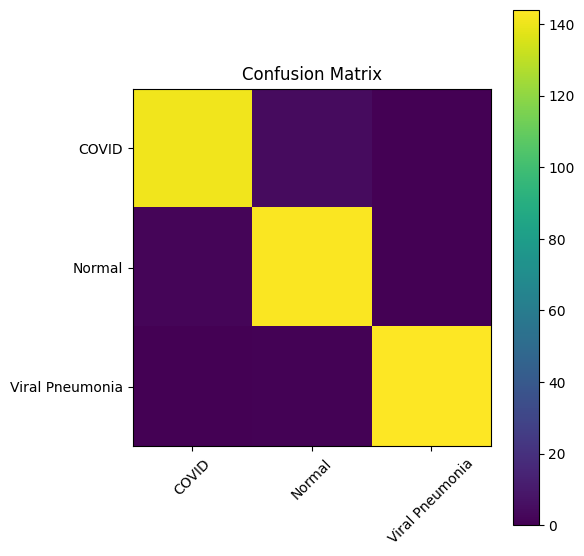

In [12]:
# CONFUSION METRIC
print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    )
)

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.xticks(
    np.arange(3),
    train_dataset.classes,
    rotation=45
)
plt.yticks(
    np.arange(3),
    train_dataset.classes
)
plt.colorbar()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.show()


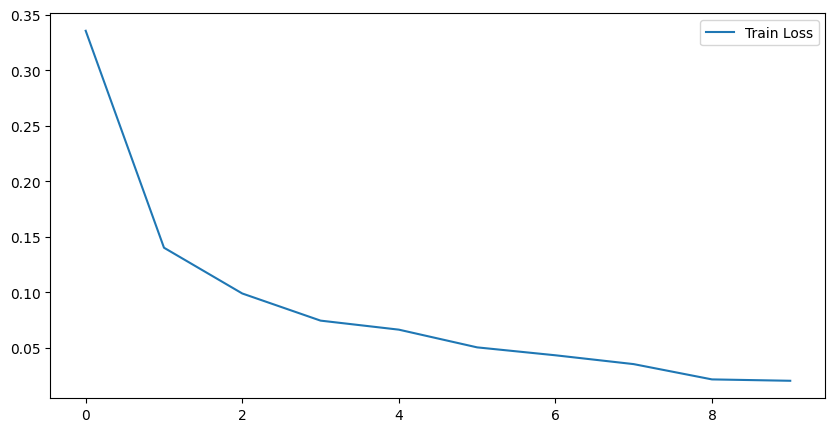

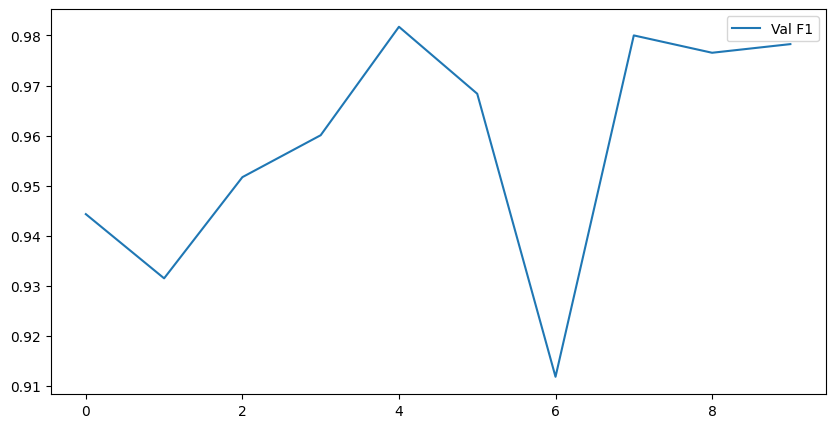

In [13]:
#TRAINING CURVES

plt.figure(figsize=(10,5))
plt.plot(train_losses,label="Train Loss")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"))
plt.show()


# VALIDATION CURVES

plt.figure(figsize=(10,5))
plt.plot(val_f1s,label="Val F1")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "f1_curve.png"))
plt.show()


######
# EXPLAINABILITY

In [18]:
# LOADING IMAGES

import cv2
import torch
import numpy as np

from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

IMG_SIZE = 224
IMG_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Explainability/Random_100_cropped"
image_dataset = os.listdir(IMG_DIR)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    rgb_img = np.array(
        img.resize((224,224))
    ) / 255.0
    return tensor, rgb_img


In [25]:
# GRAD-CAM

SAVE_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Explainability/2/CheXNet_GradCam"
target_layers = [
    model.features[-3]
]
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

for i in image_dataset:
    image_path = os.path.join(IMG_DIR, i)
    input_tensor, rgb_img = load_image(image_path)
    input_tensor = input_tensor.to(DEVICE)
    
    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]
    
    np.save(
        os.path.join(SAVE_DIR, f"saliency_maps/{os.path.splitext(i)[0]}.npy"),
        grayscale_cam
    )

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )
    
    save_path = os.path.join(SAVE_DIR, i)
    cv2.imwrite(
        save_path,
        cv2.cvtColor(
            visualization,
            cv2.COLOR_RGB2BGR
        )
    )

print(f"All Grad-Cam images saved successfully.")


All Grad-Cam images saved successfully.


In [26]:
# EXPLODING GRADIENTS

from captum.attr import IntegratedGradients

SAVE_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Explainability/2/Expl_Grad_CheXNet"
ig = IntegratedGradients(model)
output = model(input_tensor)
pred_class = output.argmax(1).item()

for i in image_dataset:
    image_path = os.path.join(IMG_DIR, i)
    input_tensor, rgb_img = load_image(image_path)
    input_tensor = input_tensor.to(DEVICE)

    attributions = ig.attribute(
        input_tensor,
        target=pred_class,
        n_steps=50
    )
    attr = (
        attributions
        .squeeze()
        .cpu()
        .detach()
        .numpy()
    )
    attr = np.mean(
        np.abs(attr),
        axis=0
    )
    attr = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)

    np.save(
        os.path.join(SAVE_DIR, f"saliency_maps/{os.path.splitext(i)[0]}.npy"),
        attr
    )

    heatmap = cv2.applyColorMap(
        np.uint8(attr*255),
        cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )
    overlay = (
        0.5*rgb_img*255
        + 0.5*heatmap
    ).astype(np.uint8)

    save_path = os.path.join(SAVE_DIR, i)
    cv2.imwrite(
        save_path,
        cv2.cvtColor(
            overlay,
            cv2.COLOR_RGB2BGR
        )
    )

print("Exploding Gradient images saved successfully.")


Exploding Gradient images saved successfully.
